<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/B05_Analisis_Conjunto_Grupo_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B05 — Análisis conjunto del Grupo B

Este notebook integra los resultados de B01, B02, B03 y B04 para cerrar el smoke test del **Grupo B — robustez de TrustMark ante manipulación facial con SimSwap**.

El objetivo ya no es generar imágenes nuevas, sino reunir toda la evidencia en una sola tabla por par:

```text
TrustMark válido antes del deepfake
        ↓
face swap exitoso
        ↓
TrustMark después del deepfake
        ↓
detección / payload / BER
        ↓
control sin watermark
```

B05 responde, de forma conjunta, a cuatro preguntas:

1. ¿TrustMark estaba correctamente presente antes del face swap?
2. ¿SimSwap realmente produjo un cambio de identidad?
3. ¿TrustMark sobrevivió después del face swap?
4. ¿Hubo falsos positivos en los controles no marcados?

Con `n = 5`, este notebook produce **resultados descriptivos del smoke test**. No se realizan todavía pruebas inferenciales ni se generaliza a todos los deepfakes.


## Lectura correcta del resultado

El resultado más fuerte que puede producir este Grupo B es la combinación:

```text
face swap exitoso
        +
TrustMark detectado
        +
payload exacto
        +
BER = 0
        +
falsos positivos = 0
```

Si ocurre, la conclusión apropiada es:

> En este piloto, TrustMark permaneció recuperable después de una manipulación facial que sí produjo desplazamiento de identidad.

Esto **no** significa todavía que TrustMark sea robusto frente a todos los deepfakes ni que una marca válida implique autenticidad del contenido. Estas preguntas más amplias quedan fuera del alcance experimental inmediato del Grupo B.


In [ ]:
# ============================================================
# CELDA 1 — Importaciones
# Importa las librerías necesarias para integrar resultados,
# construir tablas maestras, generar figuras y guardar el
# resumen final del Grupo B.
# ============================================================

from pathlib import Path
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("✓ Importaciones listas.")


✓ Importaciones listas.


In [ ]:
# ============================================================
# CELDA 2 — Google Drive y estructura del proyecto
# Monta Drive y define las rutas de entrada de B01–B04, así como
# las carpetas persistentes donde se guardará el análisis final,
# las tablas maestras, configuración y figuras de B05.
# ============================================================

try:
    from google.colab import drive

    drive.mount("/content/drive")

    ROOT = Path(
        "/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026"
    )

except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"


# ------------------------------------------------------------
# Entradas de B01
# ------------------------------------------------------------

B01_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "trustmark_targets"
    / "smoke_10"
)

B01_MANIFEST = B01_ROOT / "manifest.csv"
B01_METRICS = B01_ROOT / "metrics.csv"
B01_CONFIG = B01_ROOT / "config.json"


# ------------------------------------------------------------
# Entradas de B02
# ------------------------------------------------------------

B02_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "simswap"
    / "smoke_10"
)

B02_MANIFEST = B02_ROOT / "manifest.csv"
B02_CONFIG = B02_ROOT / "config.json"


# ------------------------------------------------------------
# Entradas de B03
# ------------------------------------------------------------

B03_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "trustmark_post_deepfake"
    / "smoke_10"
)

B03_RESULTS = B03_ROOT / "results.csv"
B03_SUMMARY = B03_ROOT / "summary.csv"
B03_CONFIG = B03_ROOT / "config.json"


# ------------------------------------------------------------
# Entradas de B04
# ------------------------------------------------------------

B04_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "face_swap_validation"
    / "smoke_10"
)

B04_IDENTITY = B04_ROOT / "identity_metrics.csv"
B04_PAIRED = B04_ROOT / "paired_comparison.csv"
B04_SUMMARY = B04_ROOT / "summary.csv"
B04_CONFIG = B04_ROOT / "config.json"


# ------------------------------------------------------------
# Salidas de B05
# ------------------------------------------------------------

OUT_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "analysis"
    / "smoke_10"
)

OUT_MASTER = OUT_ROOT / "master_table.csv"
OUT_SUMMARY = OUT_ROOT / "group_B_summary.csv"
OUT_CONCLUSION = OUT_ROOT / "conclusion.txt"
OUT_CONFIG = OUT_ROOT / "config.json"


FIG_ROOT = (
    ROOT
    / "figures"
    / "grupo_B"
    / "analysis"
)

FIG_PIPELINE = (
    FIG_ROOT
    / "group_B_pipeline_outcomes.png"
)

FIG_PAIR = (
    FIG_ROOT
    / "group_B_pair_outcomes.png"
)

FIG_IDENTITY = (
    FIG_ROOT
    / "group_B_identity_vs_watermark.png"
)


OUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


print("Resultados B05:")
print(OUT_ROOT)


Mounted at /content/drive
Resultados B05:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/analysis/smoke_10


In [ ]:
# ============================================================
# CELDA 3 — Verificación de archivos de entrada
# Comprueba que los principales resultados de B01–B04 existen
# antes de integrar la evidencia. Si falta algún archivo, B05 se
# detiene para evitar producir un resumen incompleto.
# ============================================================

required_files = {
    "B01 manifest": B01_MANIFEST,
    "B01 metrics": B01_METRICS,
    "B02 manifest": B02_MANIFEST,
    "B03 results": B03_RESULTS,
    "B03 summary": B03_SUMMARY,
    "B04 identity metrics": B04_IDENTITY,
    "B04 paired comparison": B04_PAIRED,
    "B04 summary": B04_SUMMARY,
}


missing = {
    name: path
    for name, path in required_files.items()
    if not path.exists()
}


if missing:

    for name, path in missing.items():
        print(
            f"Falta {name}:"
        )
        print(
            path
        )

    raise FileNotFoundError(
        "B05 no puede continuar porque faltan "
        "resultados de notebooks anteriores."
    )


print("✓ Todos los archivos principales de B01–B04 están disponibles.")


✓ Todos los archivos principales de B01–B04 están disponibles.


In [ ]:
# ============================================================
# CELDA 4 — Cargar resultados de B01–B04
# Lee las tablas generadas en cada etapa del Grupo B. Cada tabla
# conserva una responsabilidad distinta: watermark pre-ataque,
# archivos de SimSwap, watermark post-ataque y éxito de identidad.
# ============================================================

b01_manifest = pd.read_csv(
    B01_MANIFEST
)

b01_metrics = pd.read_csv(
    B01_METRICS
)

b02_manifest = pd.read_csv(
    B02_MANIFEST
)

b03_results = pd.read_csv(
    B03_RESULTS
)

b03_summary = pd.read_csv(
    B03_SUMMARY
)

b04_identity = pd.read_csv(
    B04_IDENTITY
)

b04_paired = pd.read_csv(
    B04_PAIRED
)

b04_summary = pd.read_csv(
    B04_SUMMARY
)


print("B01 pares:", len(b01_manifest))
print("B02 pares:", len(b02_manifest))
print("B03 filas:", len(b03_results))
print("B04 pares:", len(b04_paired))


B01 pares: 5
B02 pares: 5
B03 filas: 10
B04 pares: 5


In [ ]:
# ============================================================
# CELDA 5 — Validación de consistencia entre notebooks
# Verifica que B01, B02, B03 y B04 estén describiendo exactamente
# los mismos pair_id. Esto evita mezclar resultados provenientes
# de ejecuciones o subsets diferentes.
# ============================================================

pairs_b01 = set(
    b01_manifest[
        "pair_id"
    ].astype(str)
)

pairs_b02 = set(
    b02_manifest[
        "pair_id"
    ].astype(str)
)

pairs_b03 = set(
    b03_results[
        "pair_id"
    ].astype(str)
)

pairs_b04 = set(
    b04_paired[
        "pair_id"
    ].astype(str)
)


assert (
    pairs_b01
    == pairs_b02
    == pairs_b03
    == pairs_b04
), (
    "Los pair_id no coinciden entre B01–B04. "
    "Revisa que todos los notebooks hayan usado el mismo subset."
)


PAIR_IDS = sorted(
    pairs_b01
)


print("✓ Los cuatro notebooks utilizan los mismos pares.")
print("Pares:", PAIR_IDS)


✓ Los cuatro notebooks utilizan los mismos pares.
Pares: ['pair_001', 'pair_002', 'pair_003', 'pair_004', 'pair_005']


In [ ]:
# ============================================================
# CELDA 6 — Preparar línea base de TrustMark antes del deepfake
# Extrae de B01 si la marca estaba presente, la exactitud de bits,
# BER y recuperación exacta inmediatamente antes de SimSwap.
# ============================================================

pre = (
    b01_metrics[
        [
            "pair_id",
            "watermark_present",
            "bit_accuracy_detected",
            "ber_detected",
            "exact_recovery",
            "psnr",
            "ssim",
        ]
    ]
    .copy()
)


pre = pre.rename(
    columns={
        "watermark_present": "pre_watermark_present",
        "bit_accuracy_detected": "pre_bit_accuracy",
        "ber_detected": "pre_ber",
        "exact_recovery": "pre_exact_recovery",
        "psnr": "target_trustmark_psnr",
        "ssim": "target_trustmark_ssim",
    }
)


display(
    pre
)


,pair_id,pre_watermark_present,pre_bit_accuracy,pre_ber,pre_exact_recovery,target_trustmark_psnr,target_trustmark_ssim
0,pair_001,True,1.0,0.0,True,43.230270,0.995528
1,pair_002,True,1.0,0.0,True,41.885108,0.976207
2,pair_003,True,1.0,0.0,True,41.729964,0.973329
3,pair_004,True,1.0,0.0,True,43.359840,0.988658
4,pair_005,True,1.0,0.0,True,44.859870,0.995734


In [ ]:
# ============================================================
# CELDA 7 — Preparar resultados de TrustMark después del deepfake
# Separa la condición fake_watermarked de la condición control.
# La primera mide supervivencia de la marca; la segunda permite
# medir falsos positivos porque nunca recibió TrustMark.
# ============================================================

post_wm = (
    b03_results[
        b03_results[
            "condition"
        ] == "fake_watermarked"
    ][
        [
            "pair_id",
            "watermark_present",
            "bit_accuracy_detected",
            "ber_detected",
            "exact_recovery",
        ]
    ]
    .copy()
)


post_wm = post_wm.rename(
    columns={
        "watermark_present": "post_watermark_present",
        "bit_accuracy_detected": "post_bit_accuracy",
        "ber_detected": "post_ber",
        "exact_recovery": "post_exact_recovery",
    }
)


control = (
    b03_results[
        b03_results[
            "condition"
        ] == "fake_control"
    ][
        [
            "pair_id",
            "watermark_present",
            "exact_recovery",
        ]
    ]
    .copy()
)


control = control.rename(
    columns={
        "watermark_present": "control_watermark_detected",
        "exact_recovery": "control_exact_recovery",
    }
)


display(
    post_wm
)

display(
    control
)


,pair_id,post_watermark_present,post_bit_accuracy,post_ber,post_exact_recovery
1,pair_001,True,1.0,0.0,True
3,pair_002,True,1.0,0.0,True
5,pair_003,True,1.0,0.0,True
7,pair_004,True,1.0,0.0,True
9,pair_005,True,1.0,0.0,True


,pair_id,control_watermark_detected,control_exact_recovery
0,pair_001,False,False
2,pair_002,False,False
4,pair_003,False,False
6,pair_004,False,False
8,pair_005,False,False


In [ ]:
# ============================================================
# CELDA 8 — Preparar evidencia del éxito del face swap
# Extrae de B04 si el control y la condición watermarked lograron
# el desplazamiento relativo de identidad hacia el source, junto
# con las métricas que permiten comparar ambas ramas.
# ============================================================

identity = (
    b04_paired[
        [
            "pair_id",
            "control_source_similarity",
            "watermarked_source_similarity",
            "delta_source_similarity_wm_minus_control",
            "control_identity_margin",
            "watermarked_identity_margin",
            "fake_control_vs_fake_watermarked_identity_similarity",
            "control_swap_success",
            "watermarked_swap_success",
            "control_vs_watermarked_psnr",
            "control_vs_watermarked_ssim",
        ]
    ]
    .copy()
)


display(
    identity
)


,pair_id,control_source_similarity,watermarked_source_similarity,delta_source_similarity_wm_minus_control,control_identity_margin,watermarked_identity_margin,fake_control_vs_fake_watermarked_identity_similarity,control_swap_success,watermarked_swap_success,control_vs_watermarked_psnr,control_vs_watermarked_ssim
0,pair_001,0.605255,0.607439,0.002184,0.139539,0.159570,0.990764,True,True,42.558552,0.995066
1,pair_002,0.668386,0.656575,-0.011812,0.460089,0.437278,0.994546,True,True,42.018017,0.976321
2,pair_003,0.653174,0.670420,0.017245,0.418508,0.446663,0.992159,True,True,41.828489,0.973269
3,pair_004,0.762932,0.744765,-0.018167,0.437103,0.431918,0.993775,True,True,43.453998,0.988617
4,pair_005,0.462328,0.462759,0.000431,0.099534,0.102307,0.998771,True,True,44.866705,0.995480


In [ ]:
# ============================================================
# CELDA 9 — Construir tabla maestra por par
# Une B01, B03 y B04 en una sola fila por pair_id. Esta tabla
# permite seguir todo el recorrido experimental desde TrustMark
# pre-deepfake hasta el resultado de identidad y recuperación.
# ============================================================

master = (
    pre
    .merge(
        post_wm,
        on="pair_id",
        how="inner",
    )
    .merge(
        control,
        on="pair_id",
        how="inner",
    )
    .merge(
        identity,
        on="pair_id",
        how="inner",
    )
)


# ------------------------------------------------------------
# Variables derivadas de interpretación
# ------------------------------------------------------------

master[
    "watermark_valid_before"
] = (
    master[
        "pre_watermark_present"
    ].astype(bool)
    & master[
        "pre_exact_recovery"
    ].astype(bool)
)


master[
    "deepfake_successful"
] = master[
    "watermarked_swap_success"
].astype(bool)


master[
    "watermark_survived"
] = (
    master[
        "post_watermark_present"
    ].astype(bool)
    & master[
        "post_exact_recovery"
    ].astype(bool)
)


master[
    "control_false_positive"
] = master[
    "control_watermark_detected"
].astype(bool)


master[
    "full_experimental_success"
] = (
    master[
        "watermark_valid_before"
    ]
    & master[
        "deepfake_successful"
    ]
    & master[
        "watermark_survived"
    ]
    & ~master[
        "control_false_positive"
    ]
)


master = master.sort_values(
    "pair_id"
).reset_index(
    drop=True
)


display(
    master
)


,pair_id,pre_watermark_present,pre_bit_accuracy,pre_ber,pre_exact_recovery,target_trustmark_psnr,target_trustmark_ssim,post_watermark_present,post_bit_accuracy,post_ber,...,fake_control_vs_fake_watermarked_identity_similarity,control_swap_success,watermarked_swap_success,control_vs_watermarked_psnr,control_vs_watermarked_ssim,watermark_valid_before,deepfake_successful,watermark_survived,control_false_positive,full_experimental_success
0,pair_001,True,1.0,0.0,True,43.230270,0.995528,True,1.0,0.0,...,0.990764,True,True,42.558552,0.995066,True,True,True,False,True
1,pair_002,True,1.0,0.0,True,41.885108,0.976207,True,1.0,0.0,...,0.994546,True,True,42.018017,0.976321,True,True,True,False,True
2,pair_003,True,1.0,0.0,True,41.729964,0.973329,True,1.0,0.0,...,0.992159,True,True,41.828489,0.973269,True,True,True,False,True
3,pair_004,True,1.0,0.0,True,43.359840,0.988658,True,1.0,0.0,...,0.993775,True,True,43.453998,0.988617,True,True,True,False,True
4,pair_005,True,1.0,0.0,True,44.859870,0.995734,True,1.0,0.0,...,0.998771,True,True,44.866705,0.995480,True,True,True,False,True


In [ ]:
# ============================================================
# CELDA 10 — Tabla compacta de interpretación
# Presenta únicamente las variables más importantes para leer el
# experimento por par: marca válida antes, swap exitoso, marca
# después, exactitud del payload y falso positivo del control.
# ============================================================

compact = master[
    [
        "pair_id",
        "watermark_valid_before",
        "deepfake_successful",
        "post_watermark_present",
        "post_bit_accuracy",
        "post_ber",
        "post_exact_recovery",
        "control_false_positive",
        "watermarked_source_similarity",
        "watermarked_identity_margin",
        "full_experimental_success",
    ]
].copy()


display(
    compact
)


,pair_id,watermark_valid_before,deepfake_successful,post_watermark_present,post_bit_accuracy,post_ber,post_exact_recovery,control_false_positive,watermarked_source_similarity,watermarked_identity_margin,full_experimental_success
0,pair_001,True,True,True,1.0,0.0,True,False,0.607439,0.159570,True
1,pair_002,True,True,True,1.0,0.0,True,False,0.656575,0.437278,True
2,pair_003,True,True,True,1.0,0.0,True,False,0.670420,0.446663,True
3,pair_004,True,True,True,1.0,0.0,True,False,0.744765,0.431918,True
4,pair_005,True,True,True,1.0,0.0,True,False,0.462759,0.102307,True


In [ ]:
# ============================================================
# CELDA 11 — Resumen global del Grupo B
# Calcula los indicadores finales del smoke test: baseline de
# TrustMark, éxito del face swap, supervivencia post-deepfake,
# recuperación exacta y tasa de falsos positivos.
# ============================================================

n_pairs = len(
    master
)


group_summary = pd.DataFrame({
    "n_pairs": [
        n_pairs
    ],
    "pre_detection_rate": [
        float(
            master[
                "pre_watermark_present"
            ].mean()
        )
    ],
    "pre_exact_recovery_rate": [
        float(
            master[
                "pre_exact_recovery"
            ].mean()
        )
    ],
    "control_swap_success_rate": [
        float(
            master[
                "control_swap_success"
            ].mean()
        )
    ],
    "watermarked_swap_success_rate": [
        float(
            master[
                "watermarked_swap_success"
            ].mean()
        )
    ],
    "post_detection_rate": [
        float(
            master[
                "post_watermark_present"
            ].mean()
        )
    ],
    "post_mean_bit_accuracy_detected": [
        float(
            master[
                "post_bit_accuracy"
            ].mean()
        )
    ],
    "post_mean_ber_detected": [
        float(
            master[
                "post_ber"
            ].mean()
        )
    ],
    "post_exact_recovery_rate": [
        float(
            master[
                "post_exact_recovery"
            ].mean()
        )
    ],
    "control_false_positive_rate": [
        float(
            master[
                "control_false_positive"
            ].mean()
        )
    ],
    "mean_control_source_similarity": [
        float(
            master[
                "control_source_similarity"
            ].mean()
        )
    ],
    "mean_watermarked_source_similarity": [
        float(
            master[
                "watermarked_source_similarity"
            ].mean()
        )
    ],
    "mean_delta_source_similarity_wm_minus_control": [
        float(
            master[
                "delta_source_similarity_wm_minus_control"
            ].mean()
        )
    ],
    "mean_output_identity_similarity": [
        float(
            master[
                "fake_control_vs_fake_watermarked_identity_similarity"
            ].mean()
        )
    ],
    "mean_output_ssim": [
        float(
            master[
                "control_vs_watermarked_ssim"
            ].mean()
        )
    ],
    "full_experimental_success_rate": [
        float(
            master[
                "full_experimental_success"
            ].mean()
        )
    ],
})


display(
    group_summary
)


,n_pairs,pre_detection_rate,pre_exact_recovery_rate,control_swap_success_rate,watermarked_swap_success_rate,post_detection_rate,post_mean_bit_accuracy_detected,post_mean_ber_detected,post_exact_recovery_rate,control_false_positive_rate,mean_control_source_similarity,mean_watermarked_source_similarity,mean_delta_source_similarity_wm_minus_control,mean_output_identity_similarity,mean_output_ssim,full_experimental_success_rate
0,5,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.630415,0.628391,-0.002024,0.994003,0.985751,1.0


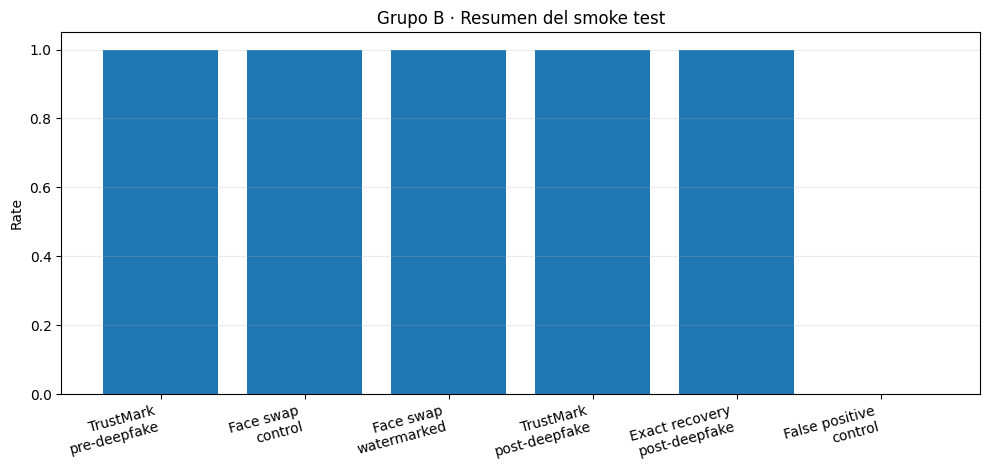

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/analysis/group_B_pipeline_outcomes.png


In [ ]:
# ============================================================
# CELDA 12 — Figura resumen del pipeline
# Resume en una sola gráfica las tasas principales del Grupo B:
# marca antes del ataque, éxito del face swap, recuperación
# después del ataque y falsos positivos del control.
# ============================================================

s = group_summary.iloc[
    0
]


labels = [
    "TrustMark\npre-deepfake",
    "Face swap\ncontrol",
    "Face swap\nwatermarked",
    "TrustMark\npost-deepfake",
    "Exact recovery\npost-deepfake",
    "False positive\ncontrol",
]


values = [
    s[
        "pre_detection_rate"
    ],
    s[
        "control_swap_success_rate"
    ],
    s[
        "watermarked_swap_success_rate"
    ],
    s[
        "post_detection_rate"
    ],
    s[
        "post_exact_recovery_rate"
    ],
    s[
        "control_false_positive_rate"
    ],
]


fig, ax = plt.subplots(
    figsize=(
        10,
        4.8,
    )
)

ax.bar(
    labels,
    values,
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_ylabel(
    "Rate"
)

ax.set_title(
    "Grupo B · Resumen del smoke test"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIG_PIPELINE,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_PIPELINE)


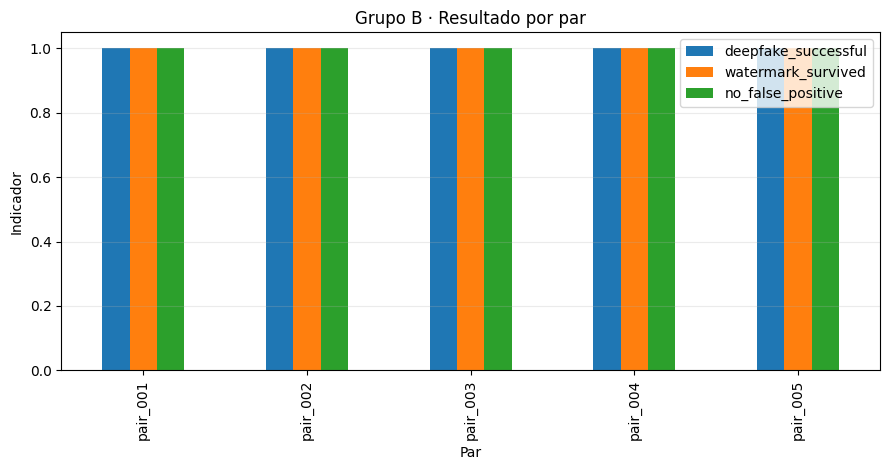

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/analysis/group_B_pair_outcomes.png


In [ ]:
# ============================================================
# CELDA 13 — Figura de resultados por par
# Visualiza por pair_id tres eventos principales: éxito del face
# swap, supervivencia exacta de TrustMark y ausencia de falso
# positivo. Permite detectar inmediatamente cualquier excepción.
# ============================================================

pair_plot = master[
    [
        "pair_id",
        "deepfake_successful",
        "watermark_survived",
    ]
].copy()


pair_plot[
    "no_false_positive"
] = ~master[
    "control_false_positive"
]


plot_matrix = (
    pair_plot
    .set_index(
        "pair_id"
    )
    .astype(int)
)


ax = plot_matrix.plot(
    kind="bar",
    figsize=(
        9,
        4.8,
    ),
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_ylabel(
    "Indicador"
)

ax.set_xlabel(
    "Par"
)

ax.set_title(
    "Grupo B · Resultado por par"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    FIG_PAIR,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_PAIR)


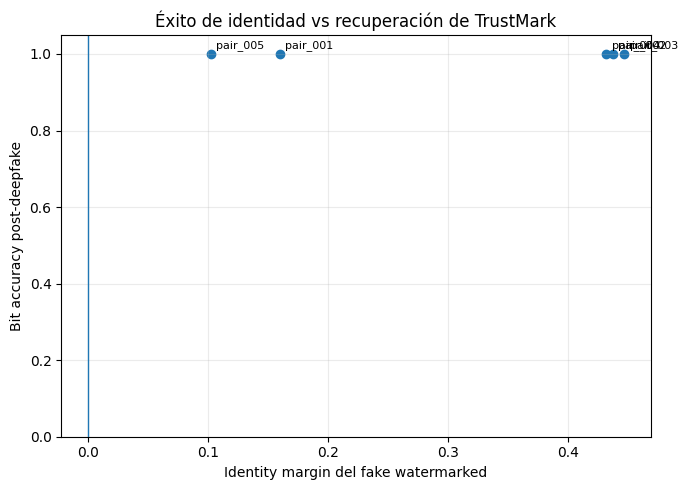

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/analysis/group_B_identity_vs_watermark.png


In [ ]:
# ============================================================
# CELDA 14 — Figura identidad vs recuperación de TrustMark
# Relaciona la evidencia de transferencia de identidad con la
# exactitud de recuperación del watermark después del deepfake.
# Esta figura ayuda a mostrar que la marca sobrevivió aun cuando
# el fake se desplazó hacia la identidad del source.
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        5,
    )
)


x = master[
    "watermarked_identity_margin"
].astype(float)

y = master[
    "post_bit_accuracy"
].astype(float)


ax.scatter(
    x,
    y,
)


for _, row in master.iterrows():

    ax.annotate(
        row[
            "pair_id"
        ],
        (
            row[
                "watermarked_identity_margin"
            ],
            row[
                "post_bit_accuracy"
            ],
        ),
        xytext=(
            4,
            4,
        ),
        textcoords="offset points",
        fontsize=8,
    )


ax.axvline(
    0,
    linewidth=1,
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_xlabel(
    "Identity margin del fake watermarked"
)

ax.set_ylabel(
    "Bit accuracy post-deepfake"
)

ax.set_title(
    "Éxito de identidad vs recuperación de TrustMark"
)

ax.grid(
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    FIG_IDENTITY,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_IDENTITY)


In [ ]:
# ============================================================
# CELDA 15 — Generar conclusión descriptiva automática
# Construye una conclusión textual basada exclusivamente en las
# métricas del smoke test. El texto evita generalizaciones más
# allá de n=5, SimSwap y la configuración TrustMark evaluada.
# ============================================================

s = group_summary.iloc[
    0
]


conclusion = (
    f"Grupo B — Smoke test (n={int(s['n_pairs'])}).\n\n"
    f"TrustMark fue detectable antes del face swap en "
    f"{s['pre_detection_rate']*100:.1f}% de los targets y el "
    f"payload se recuperó exactamente en "
    f"{s['pre_exact_recovery_rate']*100:.1f}% de los casos.\n\n"
    f"SimSwap cumplió el criterio relativo de transferencia de "
    f"identidad en {s['control_swap_success_rate']*100:.1f}% de "
    f"los controles y en "
    f"{s['watermarked_swap_success_rate']*100:.1f}% de los "
    f"targets previamente marcados.\n\n"
    f"Después del face swap, TrustMark fue detectado en "
    f"{s['post_detection_rate']*100:.1f}% de los fakes generados "
    f"desde targets marcados. La exactitud media de bits entre "
    f"las marcas detectadas fue "
    f"{s['post_mean_bit_accuracy_detected']:.3f}, con BER media "
    f"{s['post_mean_ber_detected']:.3f}, y recuperación exacta "
    f"del payload en {s['post_exact_recovery_rate']*100:.1f}% "
    f"de los casos.\n\n"
    f"La tasa de falsos positivos en fake_control fue "
    f"{s['control_false_positive_rate']*100:.1f}%.\n\n"
    f"En este piloto, la evidencia conjunta indica que TrustMark "
    f"permaneció recuperable después de manipulaciones faciales "
    f"que sí produjeron desplazamiento de identidad hacia el "
    f"source. Este resultado es descriptivo y está limitado a "
    f"cinco pares, un generador (SimSwap), un frame por par y una "
    f"configuración de TrustMark."
)


print(
    conclusion
)


Grupo B — Smoke test (n=5).

TrustMark fue detectable antes del face swap en 100.0% de los targets y el payload se recuperó exactamente en 100.0% de los casos.

SimSwap cumplió el criterio relativo de transferencia de identidad en 100.0% de los controles y en 100.0% de los targets previamente marcados.

Después del face swap, TrustMark fue detectado en 100.0% de los fakes generados desde targets marcados. La exactitud media de bits entre las marcas detectadas fue 1.000, con BER media 0.000, y recuperación exacta del payload en 100.0% de los casos.

La tasa de falsos positivos en fake_control fue 0.0%.

En este piloto, la evidencia conjunta indica que TrustMark permaneció recuperable después de manipulaciones faciales que sí produjeron desplazamiento de identidad hacia el source. Este resultado es descriptivo y está limitado a cinco pares, un generador (SimSwap), un frame por par y una configuración de TrustMark.


In [ ]:
# ============================================================
# CELDA 16 — Guardado de tablas, conclusión y configuración
# Guarda la tabla maestra, resumen global, conclusión textual y
# metadatos de B05 para que el Grupo B quede cerrado de forma
# reproducible y pueda escalarse posteriormente.
# ============================================================

master.to_csv(
    OUT_MASTER,
    index=False,
)

group_summary.to_csv(
    OUT_SUMMARY,
    index=False,
)


with open(
    OUT_CONCLUSION,
    "w",
    encoding="utf-8",
) as f:

    f.write(
        conclusion
    )


config = {
    "group": "B",
    "stage": "B05",
    "purpose": (
        "joint descriptive analysis of TrustMark survival "
        "and SimSwap identity-transfer success"
    ),
    "subset": "smoke_10",
    "n_pairs": int(
        len(
            master
        )
    ),
    "inputs": {
        "B01_manifest": str(
            B01_MANIFEST
        ),
        "B01_metrics": str(
            B01_METRICS
        ),
        "B02_manifest": str(
            B02_MANIFEST
        ),
        "B03_results": str(
            B03_RESULTS
        ),
        "B03_summary": str(
            B03_SUMMARY
        ),
        "B04_identity_metrics": str(
            B04_IDENTITY
        ),
        "B04_paired_comparison": str(
            B04_PAIRED
        ),
        "B04_summary": str(
            B04_SUMMARY
        ),
    },
    "outputs": {
        "master_table": str(
            OUT_MASTER
        ),
        "summary": str(
            OUT_SUMMARY
        ),
        "conclusion": str(
            OUT_CONCLUSION
        ),
    },
    "scope_note": (
        "Descriptive smoke test only; no inferential statistics "
        "or generalization beyond evaluated pairs/configuration."
    ),
    "python_version": sys.version,
    "platform": platform.platform(),
}


with open(
    OUT_CONFIG,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )


print("Tabla maestra:")
print(OUT_MASTER)
print()
print("Resumen:")
print(OUT_SUMMARY)
print()
print("Conclusión:")
print(OUT_CONCLUSION)
print()
print("Configuración:")
print(OUT_CONFIG)


Tabla maestra:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/analysis/smoke_10/master_table.csv

Resumen:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/analysis/smoke_10/group_B_summary.csv

Conclusión:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/analysis/smoke_10/conclusion.txt

Configuración:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/analysis/smoke_10/config.json


In [ ]:
# ============================================================
# CELDA 17 — Resumen final de B05 y cierre del Grupo B
# Presenta en consola los indicadores principales y confirma que
# el smoke test del Grupo B quedó integrado. El siguiente bloque
# experimental del proyecto será el Grupo C — localización.
# ============================================================

s = group_summary.iloc[
    0
]


print(
    "============================================================"
)

print(
    " B05 COMPLETADO — GRUPO B CERRADO"
)

print(
    "============================================================"
)

print()

print(
    f"Pares analizados:                     "
    f"{int(s['n_pairs'])}"
)

print()

print(
    "TRUSTMARK ANTES DEL DEEPFAKE"
)

print(
    f"Detection rate:                       "
    f"{s['pre_detection_rate']:.3f}"
)

print(
    f"Exact recovery rate:                  "
    f"{s['pre_exact_recovery_rate']:.3f}"
)

print()

print(
    "FACE SWAP"
)

print(
    f"Control success rate:                 "
    f"{s['control_swap_success_rate']:.3f}"
)

print(
    f"Watermarked success rate:             "
    f"{s['watermarked_swap_success_rate']:.3f}"
)

print()

print(
    "TRUSTMARK DESPUÉS DEL DEEPFAKE"
)

print(
    f"Detection rate:                       "
    f"{s['post_detection_rate']:.3f}"
)

print(
    f"Bit accuracy:                         "
    f"{s['post_mean_bit_accuracy_detected']:.3f}"
)

print(
    f"BER:                                  "
    f"{s['post_mean_ber_detected']:.3f}"
)

print(
    f"Exact recovery rate:                  "
    f"{s['post_exact_recovery_rate']:.3f}"
)

print()

print(
    "CONTROL"
)

print(
    f"False positive rate:                  "
    f"{s['control_false_positive_rate']:.3f}"
)

print()

print(
    "PIPELINE COMPLETO"
)

print(
    f"Full experimental success rate:       "
    f"{s['full_experimental_success_rate']:.3f}"
)

print()

print(
    "✓ Grupo B integrado."
)



 B05 COMPLETADO — GRUPO B CERRADO

Pares analizados:                     5

TRUSTMARK ANTES DEL DEEPFAKE
Detection rate:                       1.000
Exact recovery rate:                  1.000

FACE SWAP
Control success rate:                 1.000
Watermarked success rate:             1.000

TRUSTMARK DESPUÉS DEL DEEPFAKE
Detection rate:                       1.000
Bit accuracy:                         1.000
BER:                                  0.000
Exact recovery rate:                  1.000

CONTROL
False positive rate:                  0.000

PIPELINE COMPLETO
Full experimental success rate:       1.000

✓ Grupo B integrado.
